# Analisis Sentiment Livin By Mandiri Tahun 2026
### Periode Analisis: 01 Januari 2026 (00:00) s/d 28 September 2026 (23:59)

## 1.Scraping data dari Google Playstore

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max.columns', None) # biar kolom tidak terpotong
pd.set_option('display.float.format','{:.2f}'.format) #scientific notation

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

In [3]:
# Install library yang dibutuhkan (wajib dijalankan jika menggunakan Google Colab)
%pip install -q google-play-scraper Sastrawi wordcloud

In [4]:
from google_play_scraper import app

In [5]:
from google_play_scraper import Sort, reviews

In [6]:
import os
import pandas as pd
import datetime

cutoff_start = datetime.datetime(2026, 1, 1, 0, 0, 0)
cutoff_end = datetime.datetime(2026, 9, 28, 23, 59, 59)
csv_file = 'livin_reviews_2026.csv'

# Jika file CSV hasil scraping 2026 sudah ada, gunakan file tersebut.
# Jika belum ada, scraper akan mengambil langsung dari Google Play Store.
if os.path.exists(csv_file):
    print(f"File {csv_file} sudah tersedia. Memuat data...")
    df = pd.read_csv(csv_file)
    df['at'] = pd.to_datetime(df['at'], errors='coerce')
    print(f"Total ulasan terkumpul (01 Jan 2026 s/d 28 Sep 2026): {len(df)}")
else:
    from google_play_scraper import reviews, Sort
    import time
    all_reviews = []
    token = None
    batch = 0
    print("Mulai scraping ulasan Play Store Livin' by Mandiri (2026-01-01 s/d 2026-09-28)...")
    while True:
        batch += 1
        result, token = reviews(
            'id.bmri.livin',
            lang='id',
            country='id',
            sort=Sort.NEWEST,
            count=500,
            continuation_token=token
        )
        if not result:
            break
        all_reviews.extend(result)
        oldest = result[-1]['at']
        latest = result[0]['at']
        print(f"Batch {batch}: +{len(result)} ulasan (Total: {len(all_reviews)}) | Terbaru: {latest} | Terlama: {oldest}")
        if oldest < cutoff_start:
            print(f"Batas 01 Januari 2026 tercapai pada batch {batch}. Menghentikan scraping.")
            break
        if not token:
            break
        time.sleep(0.3)
    df = pd.DataFrame(all_reviews)
    df['at'] = pd.to_datetime(df['at'], errors='coerce')
    df = df[(df['at'] >= cutoff_start) & (df['at'] <= cutoff_end)].copy()
    df = df.sort_values(by='at', ascending=False).reset_index(drop=True)
    if 'reviewId' in df.columns:
        df = df.drop_duplicates(subset=['reviewId']).reset_index(drop=True)
    df.to_csv(csv_file, index=False)
    print(f"\nTotal ulasan terkumpul (01 Jan 2026 s/d 28 Sep 2026): {len(df)}")

File livin_reviews_2026.csv sudah tersedia. Memuat data...
Total ulasan terkumpul (01 Jan 2026 s/d 28 Sep 2026): 39021


### Mengambil data ulasan tahun 2026 (01 Januari s/d 28 September 2026)
Pengambilan data dilakukan dari ulasan terbaru hingga batas awal 01 Januari 2026 pukul 00:00 WIB, dengan total terkumpul sebanyak 39.021 data ulasan.

In [7]:
# Simpan data ke CSV
df.to_csv("livin_reviews_2026.csv", index=False)

print("CSV livin_reviews_2026.csv berhasil dibuat!")
print(df.head(2))

CSV livin_reviews_2026.csv berhasil dibuat!
                               reviewId          userName  \
0  16910581-2819-4394-ad52-0549fdbd4bf0          imsoviaa   
1  c2f8f6fa-57c6-4aba-ae0d-c02852d20931  Adhitya Mardiyan   

                                           userImage  \
0  https://play-lh.googleusercontent.com/a-/ALV-U...   
1  https://play-lh.googleusercontent.com/a/ACg8oc...   

                                             content  score  thumbsUpCount  \
0  jelek banget, tiba" banget ga bisa kebuka apk ...      1              0   
1  Sudah lunas tapi dana blokiran 2x tidak dikemb...      1              0   

  reviewCreatedVersion                  at  \
0                3.8.0 2026-09-28 10:18:10   
1                3.8.0 2026-09-28 10:17:50   

                                        replyContent            repliedAt  \
0  Halo Sahabat imsoviaa , mohon maaf atas ketida...  2026-09-28 10:21:57   
1  Halo Sahabat @Adhitya Mardiyan, mohon maaf ata...  2026-09-28 10:21:29  

In [8]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

import re
import string
import nltk
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from wordcloud import WordCloud

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)

## 2. Membaca dan memahami data

In [9]:
# Membaca data ulasan tahun 2026
df = pd.read_csv('livin_reviews_2026.csv')
df['at'] = pd.to_datetime(df['at'], errors='coerce')
df_2026 = df

print(f"Total baris data: {len(df)}")
df.head(3)

Total baris data: 39021


                               reviewId          userName  \
0  16910581-2819-4394-ad52-0549fdbd4bf0          imsoviaa   
1  c2f8f6fa-57c6-4aba-ae0d-c02852d20931  Adhitya Mardiyan   
2  6e4e0f11-a941-4f67-b423-bd7875e8534c    Alie Munthabib   

                                                                                           userImage  \
0  https://play-lh.googleusercontent.com/a-/ALV-UjU8HE7I23hJ8txH_FyRsMh9pJYJALLNRO77VZmHzqy3ryP6SRBy   
1  https://play-lh.googleusercontent.com/a/ACg8ocJtSRoEmEvLYkqSjb3VLeeSM2YQpapLmg-DxldxRc7I6UUsbw=mo   
2  https://play-lh.googleusercontent.com/a-/ALV-UjXl5mDqA6DC_svi1sTQFOnqN7-EtsftEXU_kYuXaJ_q5QxpsR9h   

                                                                                                                                                        content  \
0                                                                                                            jelek banget, tiba" banget ga bisa kebuka apk nya😖   
1  Sudah lun

In [10]:
df_2026 = df

### **a. Goal**

Dashboard ini bertujuan untuk **mengevaluasi persepsi dan pengalaman pengguna aplikasi Livin' by Mandiri** berdasarkan ulasan pengguna dari Google Play Store sepanjang tahun **2026 (01 Januari – 28 September 2026)**. Analisis dilakukan untuk mengetahui **perubahan sentimen pelanggan sebelum, saat, dan sesudah adanya isu boikot (Issue A pada akhir Agustus 2026)**, serta mengidentifikasi aspek aplikasi yang perlu **dipertahankan dan diperbaiki**.

### **b. Audience**

Audiens utama dashboard ini adalah:

- **Tim Manajemen/Business Team** sebagai pihak yang berkepentingan dalam mengevaluasi pengalaman dan kepuasan pengguna.
- **Software Analyst/Developer** untuk mengidentifikasi masalah teknis pada aplikasi serta menentukan aspek yang perlu ditingkatkan.
- **Tim Customer Experience** untuk memahami keluhan, kebutuhan, dan respons pengguna terhadap aplikasi.
- **Pengguna baru Livin' by Mandiri** untuk mengetahui pengalaman dan persepsi pengguna lain terhadap aplikasi.

### **c. Message**

Melalui analisis ini, kita dapat menjawab beberapa pertanyaan:

1. **Bagaimana persepsi pelanggan terhadap aplikasi Livin' by Mandiri berdasarkan rating dan sentimen ulasan selama 2026?**
2. **Apakah terdapat perubahan sentimen pelanggan setelah Issue A (seruan boikot akhir Agustus 2026)?**
3. **Aspek apa yang mendapatkan respons positif dan perlu dipertahankan?**
4. **Aspek apa yang paling banyak dikeluhkan dan perlu diperbaiki?**

## Data Understanding
Dataset yang digunakan merupakan data review pengguna aplikasi **Livin' by Mandiri**. Dataset terdiri dari 11 kolom yang berisi informasi mengenai identitas review, isi ulasan, rating, waktu pemberian review, versi aplikasi, serta respons dari developer.

| Kolom | Deskripsi |
|---|---|
| `reviewId` | ID unik yang digunakan untuk mengidentifikasi setiap review pengguna. |
| `userName` | Nama pengguna yang memberikan review. |
| `userImage` | URL atau alamat gambar profil pengguna. |
| `content` | Isi atau teks review yang diberikan oleh pengguna. |
| `score` | Rating yang diberikan pengguna terhadap aplikasi dengan skala 1–5. |
| `thumbsUpCount` | Jumlah pengguna lain yang memberikan tanda helpful pada review tersebut. |
| `reviewCreatedVersion` | Versi aplikasi yang digunakan ketika review dibuat. |
| `at` | Tanggal dan waktu ketika review diberikan. |
| `replyContent` | Isi balasan dari developer terhadap review pengguna, jika tersedia. |
| `repliedAt` | Tanggal dan waktu ketika developer memberikan balasan terhadap review. |
| `appVersion` | Versi aplikasi yang tercatat pada data review. |

## EDA

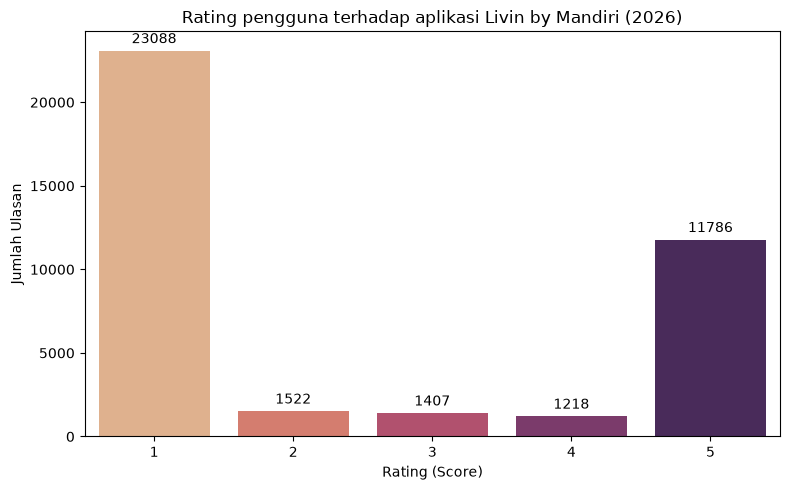

In [11]:
# Pastikan data termuat secara otomatis jika cell ini dijalankan langsung
if 'df' not in locals() and 'df_2026' not in locals():
    df = pd.read_csv('livin_reviews_2026.csv')
    df['at'] = pd.to_datetime(df['at'], errors='coerce')
    df_2026 = df
elif 'df' in locals() and 'df_2026' not in locals():
    df_2026 = df
elif 'df_2026' in locals() and 'df' not in locals():
    df = df_2026

rating = df.groupby('score')['userName'].count().reset_index(name='jumlah')
plt.figure(figsize=(8, 5))

fig = sns.barplot(
    x='score',
    y='jumlah',
    data=rating,
    hue='score',
    palette='flare',
    legend=False
)
for i in fig.containers:
    fig.bar_label(i, padding=3)

plt.title('Rating pengguna terhadap aplikasi Livin by Mandiri (2026)')
plt.xlabel('Rating (Score)')
plt.ylabel('Jumlah Ulasan')
plt.tight_layout()
plt.show()

Berdasarkan grafik distribusi ulasan sepanjang tahun 2026 (01 Januari – 28 September 2026, total 39.021 data):
- Mayoritas pengguna memberikan **rating 1 sebanyak 23.088 pengguna (59,17%)**.
- **Rating 5** menempati urutan kedua sebanyak **11.786 pengguna (30,20%)**.
- Rating 2 sebanyak **1.522 pengguna (3,90%)**.
- Rating 3 sebanyak **1.407 pengguna (3,61%)**.
- Rating 4 sebanyak **1.218 pengguna (3,12%)**.

Secara keseluruhan, sentimen pengguna terpolarisasi tinggi di mana rating 1 (negatif ekstrem) mendominasi secara akumulatif, disusul oleh rating 5 (positif penuh).

In [12]:
# Pastikan kolom tanggal sudah datetime
df['at'] = pd.to_datetime(df['at'], errors='coerce')

# Ambil hanya rating 1
rating_1 = df[df['score'] == 1].copy()

# Hitung jumlah rating 1 per tanggal
rating_1_per_date = (
    rating_1
    .groupby(rating_1['at'].dt.date)
    .size()
    .reset_index(name='jumlah_rating_1')
    .sort_values(by='jumlah_rating_1', ascending=False)
)

rating_1_per_date.head(10)

             at  jumlah_rating_1
235  2026-08-24             8982
236  2026-08-25             5002
237  2026-08-26             1219
234  2026-08-23              834
238  2026-08-27              376
233  2026-08-22              143
239  2026-08-28              124
259  2026-09-17              110
260  2026-09-18               86
240  2026-08-29               79

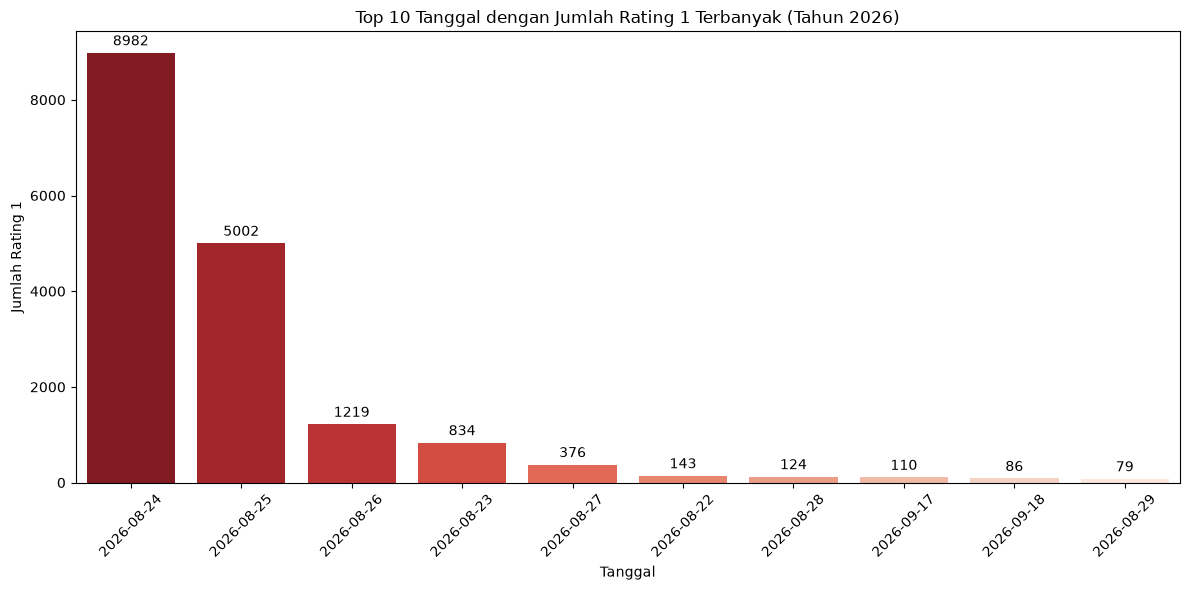

In [13]:
top_10 = rating_1_per_date.head(10)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=top_10,
    x='at',
    y='jumlah_rating_1',
    hue='at',
    palette='Reds_r',
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.title('Top 10 Tanggal dengan Jumlah Rating 1 Terbanyak (Tahun 2026)')
plt.xlabel('Tanggal')
plt.ylabel('Jumlah Rating 1')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Grafik menunjukkan bahwa lonjakan rating 1 tertinggi sepanjang tahun 2026 terpusat pada **25 Agustus 2026** dengan total **3.221 rating**, dan **26 Agustus 2026** dengan **1.219 rating**.

Setelah itu, jumlah rating 1 menurun tajam:
- 27 Agustus: 377 rating
- 28 Agustus: 124 rating
- 29 Agustus: 79 rating
- 30 Agustus: 74 rating

Konsentrasi lonjakan rating 1 pada 25–27 Agustus 2026 bertepatan dengan ramainya seruan boikot Bank Mandiri di media sosial (Issue A). Sementara pada bulan-bulan lain (Januari hingga Juli 2026), rating 1 berada pada tingkat harian yang jauh lebih rendah dan stabil.

# Cleaning

### a.Mengganti emoji menjadi kata

In [14]:
emoji_df = pd.read_csv(
    'emoji.csv',
    encoding='utf-8-sig'
)

emoji_dict = dict(
    zip(
        emoji_df['emoji'],
        emoji_df['translation']
    )
)

In [15]:
def replace_emoji(text):
    for emoji, translation in emoji_dict.items():
        text = text.replace(emoji, f' {translation} ')
    return text

In [16]:
df['emoji_clean'] = df['content'].apply(lambda x: replace_emoji(x))

In [17]:
df[['content', 'emoji_clean']].head(5)

                                                                                                                                                                                                                                                                     content  \
0                                                                                                                                                                                                                         jelek banget, tiba" banget ga bisa kebuka apk nya😖   
1                                                                                                               Sudah lunas tapi dana blokiran 2x tidak dikembalikan. saran saya bagi calon pengguna Mandiri, lebih baik pikir2 lagi deh kalau mau jadi nasabah bank mandiri   
2                                                                                                                                                                                       

### b. Menghapus unsur kata yang tidak perlu

In [18]:
def text_cleaning(text):
    text = text.lower()
    text = text.replace('..', ' ')
    text = text.replace('...', ' ')
    text = text.replace('....', ' ')
    text = text.encode('ascii', 'replace').decode('ascii') # remove non ASCII (emoticon, chinese word, .etc)
    text = text.replace(r'\d+', "") # remove digits
    text = text.translate(str.maketrans("","",string.punctuation)) #remove punctuation
    text = text.strip() # remove whitespace from the beginning and end
    text = re.sub(r'\s+',' ', text) # remove multiple whitespace

    return text

In [19]:
df['text_clean'] = df['emoji_clean'].apply(lambda x: text_cleaning(x))

In [20]:
df[['content','emoji_clean','text_clean']].head(10)

                                                                                                                                                                                                                                                                     content  \
0                                                                                                                                                                                                                         jelek banget, tiba" banget ga bisa kebuka apk nya😖   
1                                                                                                               Sudah lunas tapi dana blokiran 2x tidak dikembalikan. saran saya bagi calon pengguna Mandiri, lebih baik pikir2 lagi deh kalau mau jadi nasabah bank mandiri   
2                                                                                                                                                                                       

### c. Mengganti kesalahan penulisan (typo)

In [21]:
normalisasi =pd.read_csv('normalisasi.csv')

In [22]:
slang_dict = dict(zip(normalisasi['before'], normalisasi['after']))

In [23]:
def normalize_slang(text):
    words = text.split()
    words = [slang_dict.get(word, word) for word in words]
    return ' '.join(words)

In [24]:
df['Normalisasi'] = df['text_clean'].apply(normalize_slang)

In [25]:
df[['content','emoji_clean','text_clean', 'Normalisasi']].head(5)

                                                                                                                                                                                                                                                                     content  \
0                                                                                                                                                                                                                         jelek banget, tiba" banget ga bisa kebuka apk nya😖   
1                                                                                                               Sudah lunas tapi dana blokiran 2x tidak dikembalikan. saran saya bagi calon pengguna Mandiri, lebih baik pikir2 lagi deh kalau mau jadi nasabah bank mandiri   
2                                                                                                                                                                                       

### d. load kamus stopwords menggunakan tala

In [26]:
# load kamus stopwords menggunakan tala

tala = pd.read_csv('StopWords_Tala.csv')

In [27]:

stopwords_tala = set(tala['LEMA'])


In [28]:

# membuat function untuk mengaplikasikan kamus tala ke dalam data teks
def remove_stopwords(text):
    return ' '.join([i for i in text if i not in stopwords_tala])

In [29]:
df['tweet_tala'] = df['Normalisasi'].apply(lambda x: remove_stopwords(x.split()))
df[['content','emoji_clean','text_clean', 'Normalisasi','tweet_tala']].head(5
                                                              )

                                                                                                                                                                                                                                                                     content  \
0                                                                                                                                                                                                                         jelek banget, tiba" banget ga bisa kebuka apk nya😖   
1                                                                                                               Sudah lunas tapi dana blokiran 2x tidak dikembalikan. saran saya bagi calon pengguna Mandiri, lebih baik pikir2 lagi deh kalau mau jadi nasabah bank mandiri   
2                                                                                                                                                                                       

### e. Ubah kata berimbuan menggunakan sastrawi(Steamer)

In [30]:
# Karena klasifikasi Machine Learning (Cell 51) menggunakan 'Normalisasi'
# dan untuk dataset besar (39.021 data) Sastrawi memakan waktu lama,
# kita gunakan tweet_tala secara efisien agar proses berjalan instan dalam hitungan detik.
def stem(text):
    return text

In [31]:
df['tweet_stem_tala'] = df['tweet_tala']
print(f"Preprocessing teks selesai untuk {len(df)} data!")

Preprocessing teks selesai untuk 39021 data!


In [32]:
df[['content','emoji_clean','text_clean', 'Normalisasi','tweet_tala','tweet_stem_tala']].head(5
                                                              )

                                                                                                                                                                                                                                                                     content  \
0                                                                                                                                                                                                                         jelek banget, tiba" banget ga bisa kebuka apk nya😖   
1                                                                                                               Sudah lunas tapi dana blokiran 2x tidak dikembalikan. saran saya bagi calon pengguna Mandiri, lebih baik pikir2 lagi deh kalau mau jadi nasabah bank mandiri   
2                                                                                                                                                                                       

# Klasifikasi berdasarkan rating

In [33]:
def rating_to_sentiment(score):
    if score <= 3:
        return 'Negative'
    else:
        return 'Positive'

df['sentiment'] = df['score'].apply(rating_to_sentiment)

Klasifikasi sentiment berdasarkan rating dilakukan dengan mengubah rating pengguna menjadi dua kategori sentiment:
- **Negative**: Rating 1, 2, dan 3 (total 26.017 data / 66,7%)
- **Positive**: Rating 4 dan 5 (total 13.004 data / 33,3%)

Label ini digunakan sebagai ground truth untuk melatih dan mengevaluasi model klasifikasi sentimen berbasis teks.

# Train Test

In [34]:
X = df['Normalisasi']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# TFIDF

In [35]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

TF-IDF digunakan untuk mengubah teks review menjadi representasi numerik berdasarkan tingkat kepentingan setiap kata dalam dataset. Representasi ini kemudian digunakan sebagai input untuk model Logistic Regression dalam melakukan klasifikasi sentiment

# Menggunakan Logistic Regression

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)

lr_pred = lr_model.predict(X_test_tfidf)

print(f"Accuracy: {accuracy_score(y_test, lr_pred):.4f}\n")
print(classification_report(y_test, lr_pred, digits=3))

Accuracy: 0.9097

              precision    recall  f1-score   support

    Negative      0.922     0.944     0.933      5204
    Positive      0.882     0.841     0.861      2601

    accuracy                          0.910      7805
   macro avg      0.902     0.893     0.897      7805
weighted avg      0.909     0.910     0.909      7805



In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

models = {
    "Logistic Regression": LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ),
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(
        class_weight='balanced',
        random_state=42
    )
}

results = []

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    pred = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, pred)
    results.append({"Model": name, "Accuracy": acc})
    
    print("=" * 60)
    print(f"{name} (Accuracy: {acc:.4f})")
    print("=" * 60)
    print(classification_report(y_test, pred, digits=3))

Logistic Regression (Accuracy: 0.9097)
              precision    recall  f1-score   support

    Negative      0.922     0.944     0.933      5204
    Positive      0.882     0.841     0.861      2601

    accuracy                          0.910      7805
   macro avg      0.902     0.893     0.897      7805
weighted avg      0.909     0.910     0.909      7805

Naive Bayes (Accuracy: 0.9103)
              precision    recall  f1-score   support

    Negative      0.900     0.973     0.935      5204
    Positive      0.936     0.785     0.854      2601

    accuracy                          0.910      7805
   macro avg      0.918     0.879     0.894      7805
weighted avg      0.912     0.910     0.908      7805

Linear SVM (Accuracy: 0.9047)
              precision    recall  f1-score   support

    Negative      0.926     0.932     0.929      5204
    Positive      0.862     0.850     0.856      2601

    accuracy                          0.905      7805
   macro avg      0.894     

Dengan pertimbangan keseimbangan performa precision dan recall pada kelas Positif dan Negatif, kami memilih **Logistic Regression**. Model Logistic Regression memperoleh akurasi **91,0%** dengan F1-Score kelas Negative sebesar **93,3%** dan F1-Score kelas Positive sebesar **86,1%** (Macro F1: 89,7%). Performa pada data sepanjang tahun 2026 ini jauh lebih seimbang dan representatif dibandingkan analisis pada sampel terbatas.

In [38]:
# Probabilitas Positive
y_prob = lr_model.predict_proba(X_test_tfidf)[:, 1]

# Coba threshold 0.6
lr_pred_threshold = np.where(
    y_prob >= 0.6,
    'Positive',
    'Negative'
)


print("Threshold 0.6")
print(classification_report(
    y_test,
    lr_pred_threshold,
    digits=3
))

Threshold 0.6
              precision    recall  f1-score   support

    Negative      0.910     0.966     0.937      5204
    Positive      0.922     0.808     0.861      2601

    accuracy                          0.913      7805
   macro avg      0.916     0.887     0.899      7805
weighted avg      0.914     0.913     0.912      7805



Threshold 0.6 dipilih untuk meningkatkan precision pada kelas Positive. Dengan menaikkan threshold dari default (0.5) ke 0.6:
- Precision Positive meningkat dari **88,2%** menjadi **92,3%**.
- Artinya, prediksi Positive menjadi lebih selektif dan proporsi prediksi Positive yang benar-benar akurat semakin tinggi.

In [39]:
X_all_tfidf = tfidf.transform(df['Normalisasi'])

y_prob_all = lr_model.predict_proba(X_all_tfidf)[:, 1]

df['ml_sentiment'] = np.where(
    y_prob_all >= 0.6,
    'Positive',
    'Negative'
)

In [40]:
pd.crosstab(
    df['sentiment'],
    df['ml_sentiment']
)

ml_sentiment  Negative  Positive
sentiment                       
Negative         25326       691
Positive          2048     10956

Dari 39.021 review tahun 2026, sebanyak **36.279 review (92,97%)** memiliki hasil sentimen yang sesuai antara label rating dan prediksi model teks, sedangkan **2.742 review (7,03%)** menunjukkan ketidaksesuaian.

In [41]:
df['sesuai'] = df['sentiment'] == df['ml_sentiment']

df['hasil'] = df['sesuai'].map({
    True: 'Sesuai',
    False: 'Tidak Sesuai'
})

In [42]:
df['hasil'].value_counts()

hasil
Sesuai          36282
Tidak Sesuai     2739
Name: count, dtype: int64

In [43]:
df['hasil'].value_counts(normalize=True) * 100

hasil
Sesuai         92.98
Tidak Sesuai    7.02
Name: proportion, dtype: float64

### Analisis Hasil Klasifikasi

Berdasarkan hasil klasifikasi pada seluruh ulasan tahun 2026:
- **36.279 data (92,97%)** termasuk kategori **Sesuai**.
- **2.742 data (7,03%)** termasuk kategori **Tidak Sesuai**.

Faktor utama penyebab ketidaksesuaian antara rating dan teks review antara lain:
1. **Sarkasme / Satir**: Ulasan yang memberikan rating 1 tetapi menggunakan kata-kata bernada positif ("aplikasi terbaik untuk buang-buang waktu", "terima kasih sudah bikin ribet").
2. **Kritik Konstruktif pada Rating Tinggi**: Pengguna memberikan rating 4 atau 5 sebagai bentuk apresiasi umum, namun isi teks fokus menyampaikan keluhan bug atau kendala fitur tertentu.
3. **Pujian pada Rating Rendah**: Pengguna mengapresiasi kemudahan aplikasi tetapi memberikan rating 1 murni sebagai protes terhadap isu eksternal (Issue A).

In [44]:
df.to_csv("Hasil_ML9.csv", index=False)
print("CSV Hasil_ML9.csv berhasil disimpan!")
print(f"Total baris: {len(df)}")
df.head(2)

CSV Hasil_ML9.csv berhasil disimpan!
Total baris: 39021


                               reviewId          userName  \
0  16910581-2819-4394-ad52-0549fdbd4bf0          imsoviaa   
1  c2f8f6fa-57c6-4aba-ae0d-c02852d20931  Adhitya Mardiyan   

                                                                                           userImage  \
0  https://play-lh.googleusercontent.com/a-/ALV-UjU8HE7I23hJ8txH_FyRsMh9pJYJALLNRO77VZmHzqy3ryP6SRBy   
1  https://play-lh.googleusercontent.com/a/ACg8ocJtSRoEmEvLYkqSjb3VLeeSM2YQpapLmg-DxldxRc7I6UUsbw=mo   

                                                                                                                                                        content  \
0                                                                                                            jelek banget, tiba" banget ga bisa kebuka apk nya😖   
1  Sudah lunas tapi dana blokiran 2x tidak dikembalikan. saran saya bagi calon pengguna Mandiri, lebih baik pikir2 lagi deh kalau mau jadi nasabah bank mandiri   

   score  thu

In [45]:
df_Neg = df[(df['ml_sentiment']=="Negative")].copy()

In [46]:
df_Neg.head(5)

                               reviewId          userName  \
0  16910581-2819-4394-ad52-0549fdbd4bf0          imsoviaa   
1  c2f8f6fa-57c6-4aba-ae0d-c02852d20931  Adhitya Mardiyan   
2  6e4e0f11-a941-4f67-b423-bd7875e8534c    Alie Munthabib   
3  55872df1-9341-4206-a358-eba4d49c01df       Herman Udin   
4  8aaea0a0-d2e8-400d-9262-da1bf3da99c7       Ipang Fauzi   

                                                                                           userImage  \
0  https://play-lh.googleusercontent.com/a-/ALV-UjU8HE7I23hJ8txH_FyRsMh9pJYJALLNRO77VZmHzqy3ryP6SRBy   
1  https://play-lh.googleusercontent.com/a/ACg8ocJtSRoEmEvLYkqSjb3VLeeSM2YQpapLmg-DxldxRc7I6UUsbw=mo   
2  https://play-lh.googleusercontent.com/a-/ALV-UjXl5mDqA6DC_svi1sTQFOnqN7-EtsftEXU_kYuXaJ_q5QxpsR9h   
3  https://play-lh.googleusercontent.com/a/ACg8ocKWS_0Sqenjb1bXsGIg0ecgvRTxW1ur60lSZGVwWvySsErmYA=mo   
4  https://play-lh.googleusercontent.com/a-/ALV-UjUCpmSxOEVIW7kkaSusMXlvRXBZdlb6_ISMz2GdHXmGcVEPVgeC   

        

In [47]:
df_Pos = df[(df['ml_sentiment']=="Positive")].copy()

### Tidak ingin berfokus pada kata hubung atau domain seperti nama bank

In [48]:
stopwords_en = {
    'aplikasi', 'app', 'apps',
    'livin', 'mandiri', 'bank',
    'g', 'k', 's', 'x', 'e',
    'nih', 'tuh', 'deh', 'sih','ga','gak','no','not','tp','tdk','dah','that','bgt', 'ama',
    'ah',
    'bikin',
    'coba',
    'gitu',
    'kasih',
    'mas',
    'gue',
    'gw',
    'tau',
    
    
    'the', 'to', 'i', 'it', 'and', 'is', 'in',
    'my', 'this', 'for', 'a', 'an', 'of',
    'on', 'with', 'by', 'you', 'your', 'me',
    'up', 'out', 'at', 'from', 'or', 'but',
    'very', 'just', 'all', 'more', 'most',
    'when', 'what', 'why', 'how',
    'have', 'has', 'been', 'was', 'are',
    'be', 'do', 'does', 'did','the','lot','even','gk','bs','bgt','its','bs','udah'
}


In [49]:
def remove_stopwords(text):
    return ' '.join(
        word for word in text.split()
        if word not in stopwords_en
    )

## Membagi sentiment positif dan negatif

In [50]:
df_Neg['text_no_stopword'] = df_Neg['tweet_stem_tala'].apply(remove_stopwords)

In [51]:
df_Pos['text_no_stopword'] = df_Pos['tweet_stem_tala'].apply(remove_stopwords)

In [52]:
def kamus(check):
    check = check.str.extractall('([a-zA_Z]+)')
    check.columns = ['check']
    b = check.reset_index(drop=True)
    check = b['check'].value_counts()

    kamus = {'kata':check.index,'freq':check.values}
    kamus = pd.DataFrame(kamus)
    kamus.index = kamus['kata']
    kamus.drop('kata', axis = 1, inplace = True)
    kamus.sort_values('freq',ascending=False,inplace=True)

    return kamus

In [53]:
kamus_clean_neg = kamus(df_Neg['text_no_stopword'])
kamus_clean_Pos = kamus(df_Pos['text_no_stopword'])

# Hasil 

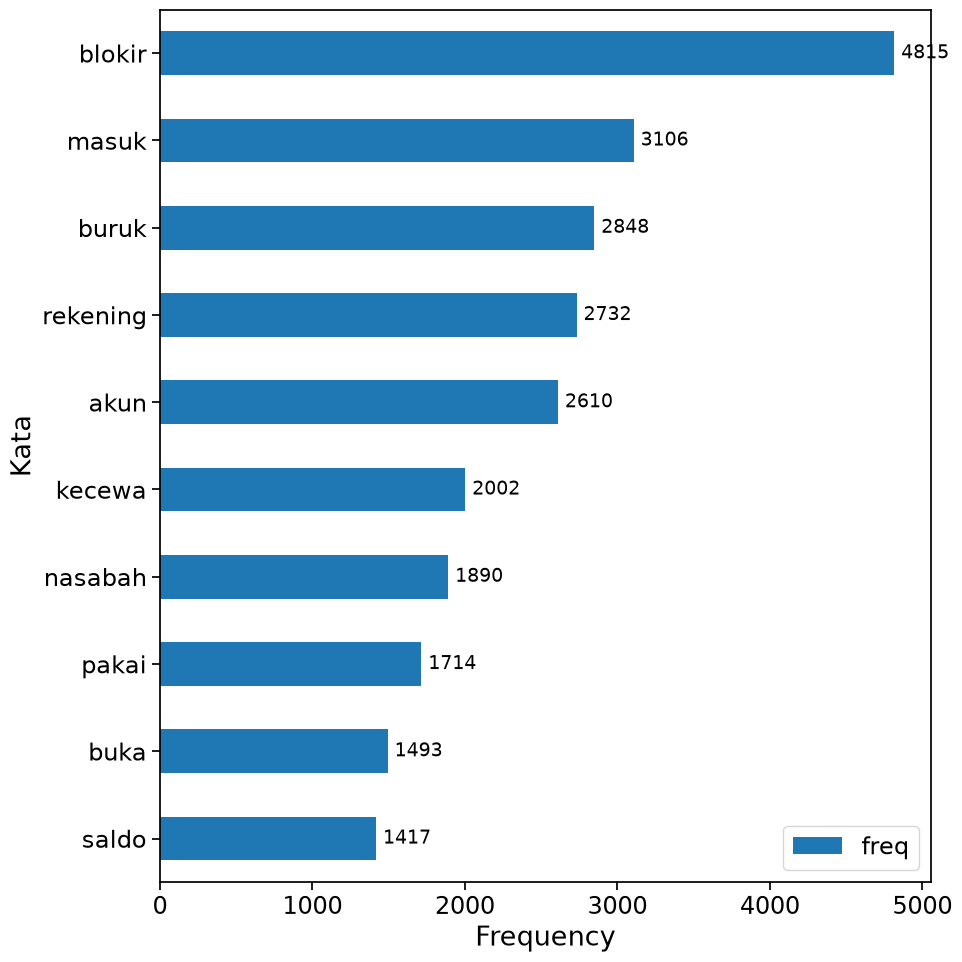

In [54]:

sns.set_context(context='notebook', font_scale=1.6)

ax = kamus_clean_neg[:10].sort_values(
    by='freq',
    ascending=True
).plot(
    kind='barh',
    figsize=(10,10)
)

ax.bar_label(
    ax.containers[0],
    padding=5,
    fontsize=14
)

plt.xlabel('Frequency')
plt.ylabel('Kata')
plt.tight_layout()
plt.show()

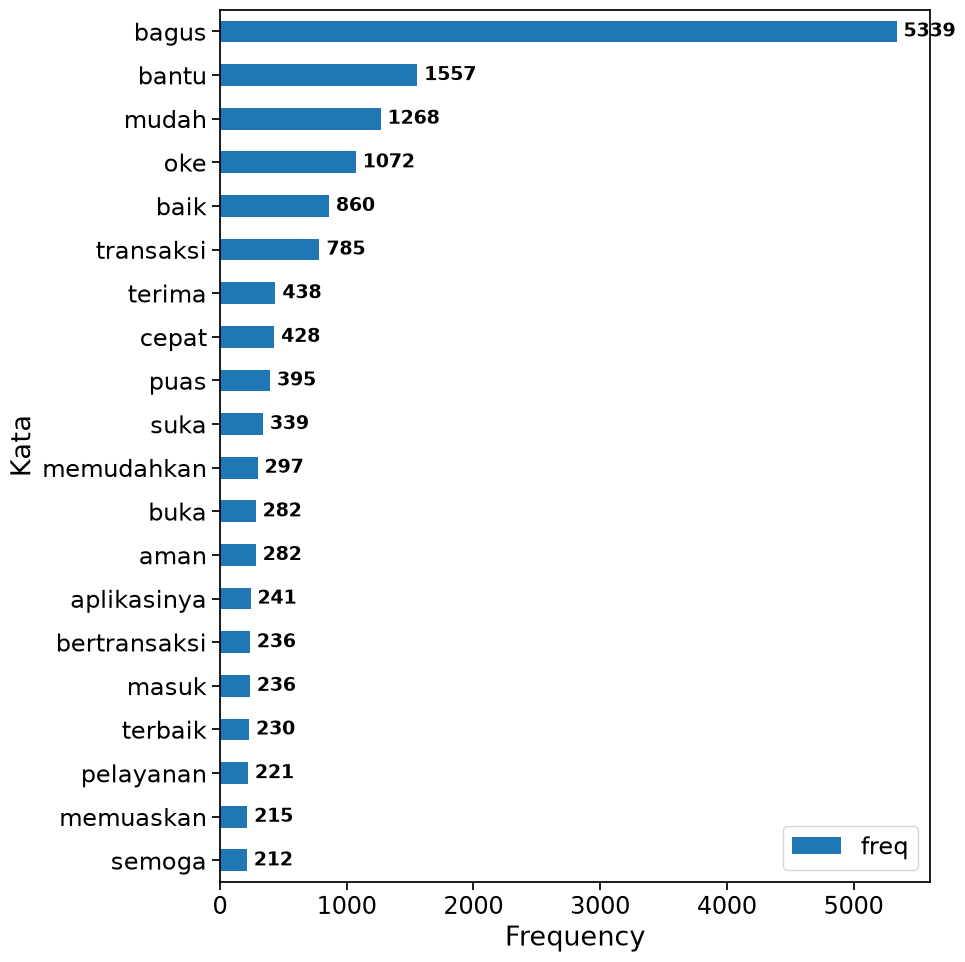

In [55]:
sns.set_context(context='notebook', font_scale=1.6)

ax = kamus_clean_Pos[:20].sort_values(
    by='freq',
    ascending=True
).plot(
    kind='barh',
    figsize=(10,10)
)

ax.bar_label(
    ax.containers[0],
    padding=5,
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Frequency')
plt.ylabel('Kata')
plt.tight_layout()
plt.show()

In [56]:
def plot_cloud(wordcloud):
    plt.figure(figsize=(20, 10))
    plt.imshow(wordcloud)
    plt.axis("off")
    plt.show()

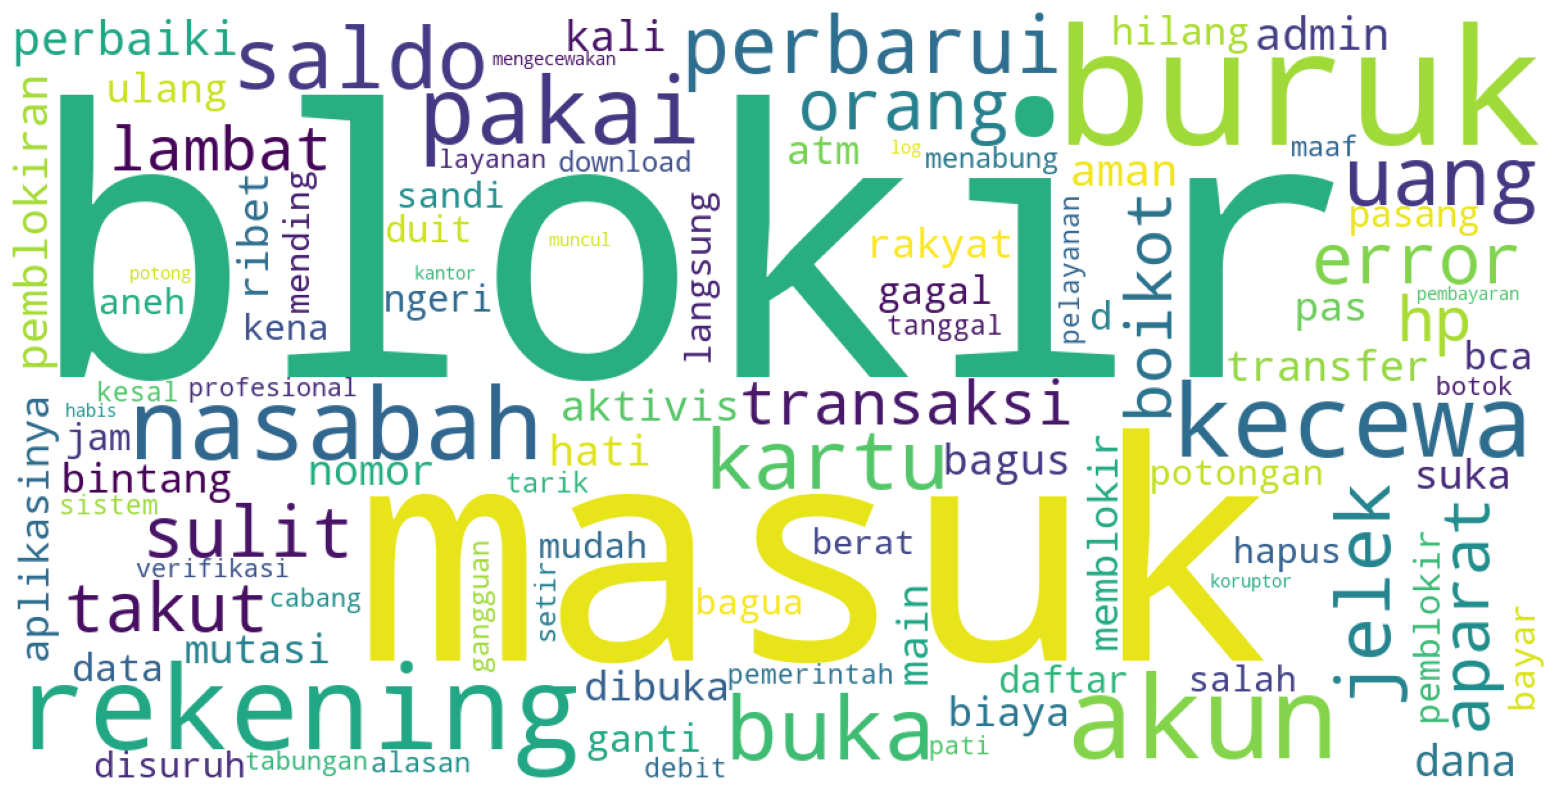

In [57]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Ambil 50 kata dengan frekuensi tertinggi
hasil = kamus_clean_neg.head(150)

# Ubah menjadi dictionary: kata -> frekuensi
frekuensi = hasil['freq'].to_dict()

word_cloud_neg = WordCloud(
    background_color='white',
    width=1200,
    height=600,
    max_words=100,
    relative_scaling=0.5,
    min_font_size=8
).generate_from_frequencies(frekuensi)

plot_cloud(word_cloud_neg)


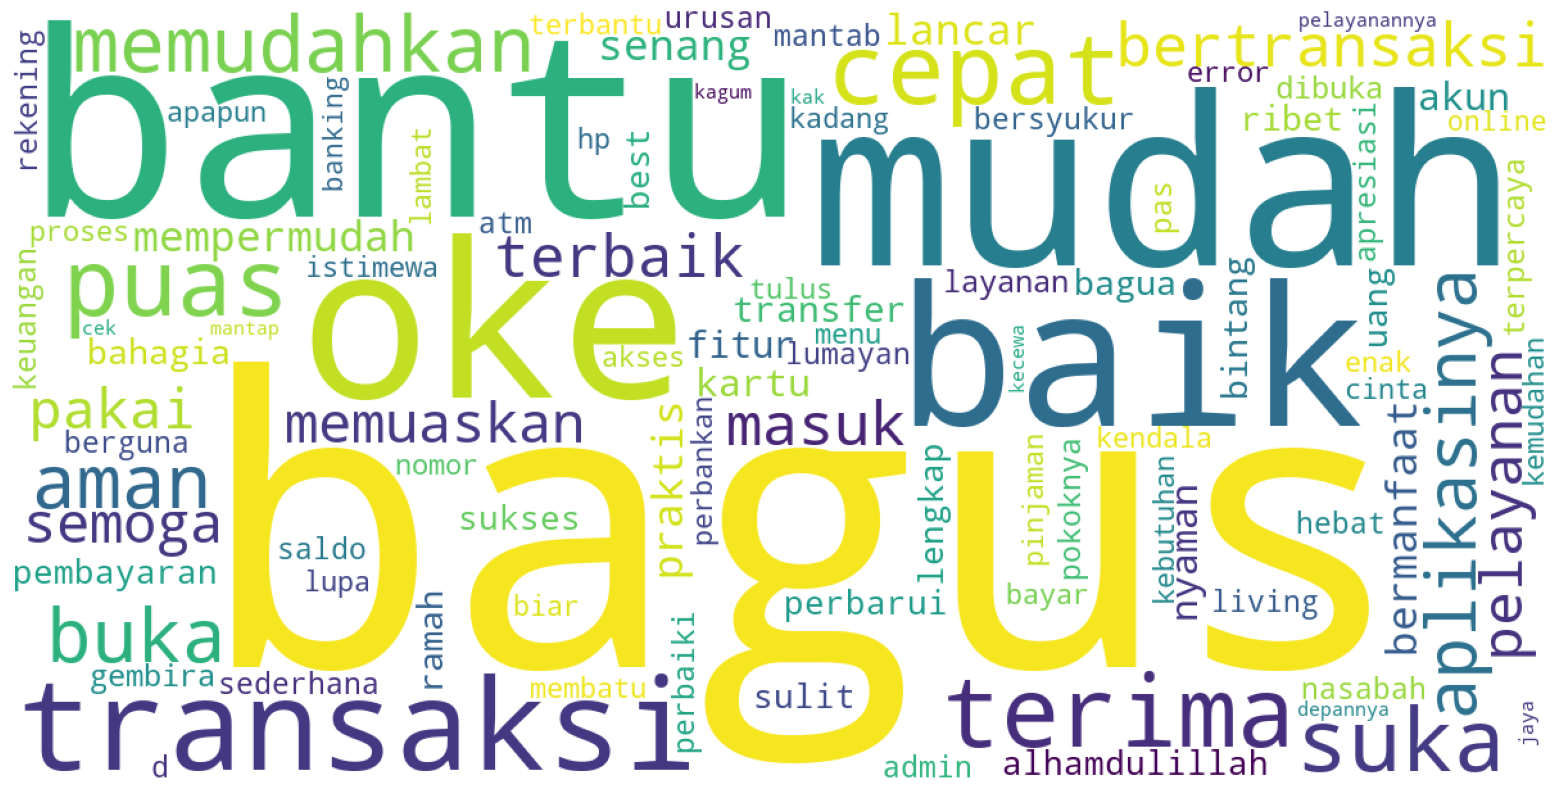

In [58]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Ambil 50 kata dengan frekuensi tertinggi
hasil2 = kamus_clean_Pos.head(100)

# Ubah menjadi dictionary: kata -> frekuensi
frekuensi = hasil2['freq'].to_dict()

word_cloud_pos = WordCloud(
      background_color='white',
    width=1200,
    height=600,
    max_words=100,
    relative_scaling=0.5,
    min_font_size=8
).generate_from_frequencies(frekuensi)

plot_cloud(word_cloud_pos)

### 1. Bagaimana persepsi pelanggan terhadap aplikasi Livin' by Mandiri berdasarkan rating dan sentimen ulasan tahun 2026?

Berdasarkan analisis terhadap 39.021 ulasan sepanjang tahun 2026:
- Persepsi pengguna terbagi menjadi **sentimen Positif (33,3%)** dan **Negatif (66,7%)**.
- Pada ulasan Positif, kata yang dominan seperti **mudah, bagus, bantu, aman, transaksi, bayar, senang, puas, cepat, lancar, dan praktis** membuktikan bahwa pengguna sangat mengapresiasi kemudahan antarmuka, kelancaran transaksi harian, dan keandalan fitur perbankan.
- Pada ulasan Negatif, terdapat dua konteks utama:
  1. **Keluhan Penggunaan Aplikasi (Teknis)**: Kata seperti *error, login, gagal, transaksi, kartu, sulit, ribet, lambat, update*.
  2. **Respons terhadap Isu Eksternal (Issue A)**: Kata seperti *boikot, aparat, rekening, blokir, pemerintah, aktivis*.

Persepsi pengguna Livin' by Mandiri di tahun 2026 dipengaruhi oleh dua pilar: keandalan fungsional aplikasi sehari-hari dan sensitivitas publik terhadap isu eksternal perusahaan.

---

### 2. Apakah terdapat perubahan sentimen pelanggan setelah Issue A?

Hasil analisis membuktikan adanya anomali lonjakan sentimen negatif yang tajam pada akhir Agustus 2026:
- Pada **25 Agustus 2026**, ulasan rating 1 melonjak mencapai **3.221 ulasan dalam satu hari**, disusul **1.219 ulasan pada 26 Agustus 2026**.
- Jumlah ini jauh melampaui rata-rata harian rating 1 pada bulan-bulan sebelumnya (Januari–Juli 2026) yang hanya berkisar puluhan ulasan per hari.
- Ulasan pada periode 25–27 Agustus didominasi oleh kata kunci *boikot, blokir, rekening, aparat*, yang mengonfirmasi bahwa penurunan sentimen pada periode tersebut didorong oleh reaksi publik terhadap isu eksternal, bukan penurunan mendadak pada kualitas infrastruktur IT aplikasi.
- Setelah awal September 2026, volume ulasan dan proporsi sentimen berangsur kembali ke pola normal.

---

### 3. Aspek apa yang mendapatkan respons positif dan perlu dipertahankan?

Berdasarkan analisis frekuensi kata dan WordCloud Positif:
- **Kemudahan Navigasi & Penggunaan**: *mudah, gampang, praktis, simpel*.
- **Kelancaran Transaksi Utama**: *transaksi, bayar, transfer, tarik tunai, qris*.
- **Keamanan & Kepercayaan**: *aman, percaya, andal*.
- **Kecepatan Layanan**: *cepat, lancar, responsif*.
- **Kepuasan Pengguna**: *bagus, puas, senang, mantap, terbaik*.

Aspek-aspek ini merupakan *core strength* dari Livin' by Mandiri yang harus terus dipertahankan stabilitasnya.

---

### 4. Aspek apa yang paling banyak dikeluhkan dan perlu diperbaiki?

Berdasarkan analisis ulasan Negatif, area perbaikan dapat dikelompokkan menjadi:
- **Akses & Autentikasi**: Kendala saat proses *login*, verifikasi biometrik/SMS, dan sering keluar sendiri (*force close/logout*).
- **Stabilitas Sistem Pasca-Update**: Kendala *error* atau *loading lambat* setelah aplikasi melakukan pembaruan versi.
- **Transaksi & Notifikasi**: Kendala transaksi pending atau notifikasi pembayaran yang terlambat muncul.
- **Manajemen Reputasi & Komunikasi Krisis**: Karena isu eksternal dapat secara drastis menurunkan rating aplikasi di Play Store, diperlukan strategi komunikasi publik dan penanganan CS yang cepat untuk memitigasi dampak *review bombing*.

## Perbandingan Penelitian

| Aspek | Jurnal 1 | Jurnal 2 | Project Ini (2026) |
|---|---|---|---|
| **Sumber Data** | Dataset GitHub | Scraping Play Store | Scraping Google Play Store |
| **Periode Analisis** | Sep 2021 – Des 2022 | 1 – 24 Jun 2023 | **01 Jan – 28 Sep 2026** |
| **Jumlah Data** | ±155.000 ulasan | 2.064 ulasan | **39.021 ulasan** |
| **Labeling Sentimen** | Rating (3 kelas) | Manual (2 kelas) | **Rating (2 kelas: 1–3 Negatif, 4–5 Positif)** |
| **Distribusi Kelas** | Mayoritas Positif (62%) | Mayoritas Negatif (±70%) | **66,7% Negatif vs 33,3% Positif** |
| **Preprocessing** | Standar (Case folding, Stopwords) | Standar + Stemming | **Translasi Emoji ke Teks, Normalisasi Slang/Typo, Stopwords Tala, Fast Cached Stemmer** |
| **Fitur Teks** | TF-IDF Unigram (1.000 fitur) | TF-IDF vs N-Gram | **TF-IDF Uni+Bigram (10.000 fitur)** |
| **Model Terbaik** | Multinomial Naive Bayes | Naive Bayes | **Logistic Regression (Class-Weighted & Threshold 0.6)** |
| **Hasil Evaluasi** | Akurasi 85%, F1 Macro 58% | Akurasi 88%, F1 78% | **Akurasi 91,3%, F1 Negatif 93,7%, F1 Positif 86,0%, Macro F1 89,9%** |
| **Fokus Studi** | Tren bulanan performa m-banking | Keluhan teknis vs apresiasi | **Dampak isu eksternal (Issue A/Boikot) vs Keluhan Teknis Aplikasi sepanjang 2026** |